In [61]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

# inputs
path_archive = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/'
UKESM_ARISE_run_IDs = ['cl322', 'cl458', 'cl459', 'cl460', 'cl461']
UKESM_ARISE_run_dict = {'cl322':'r1i1p1f2', 'cl458':'r2i1p1f2', 'cl459':'r3i1p1f2',
                        'cl460':'r4i1p1f2', 'cl461':'r8i1p1f2'}
ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']
CESM_ARISE_run_IDs = ['001', '002', '003', '004', '005'] # note there ten members, but we use only 5 here to align UKESM
ens_mems_CE = ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1', 'r5i1p1f1']

ens_mems_UK_ssp245_all = ['r10i1p1f2','r11i1p1f2','r12i1p1f2','r16i1p1f2',
                          'r17i1p1f2','r18i1p1f2','r19i1p1f2','r1i1p1f2',
                          'r2i1p1f2','r3i1p1f2','r4i1p1f2','r5i1p1f2',
                          'r6i1p1f2','r7i1p1f2','r8i1p1f2','r9i1p1f2']

UKESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/UKESM_feedback_stats/'
CESM_arise_inj_logs_path = '../../Extra_data/ARISE_injection_stats/CESM_feedback_stats/'
HiLLA_inj_mag = 12 # Tg per year total (6Tg per hemisphere)

unit_conversion_ms_to_mm_month = 1000*3600*30
unit_conversion_kg = 86400

In [2]:
### Settings
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'HiLLA_13':'red',
           'HiLLA_15':'green'}

model_colors = {'UKESM':'salmon',
                'CESM':'lightskyblue',
                'E3SM':'seagreen'}

models = ['UKESM', 'CESM', 'E3SM']

HiLLA_altitudes = ['13km', '15km']

assessment_period = [2050, 2069]

lat_band_dict = {'Tropics':[-23, 23], 
                 'Arctic':[66, 91],
                 'Antarctic':[-91, -66],
                 'Global':[-91, 91],
                 'NH':[0, 91],
                 'SH':[-91, 0]}

regions = ['Global', 'Arctic', 'Tropics', 'NH', 'SH', 'Antarctic']

In [3]:
def get_ds(run, var, table, zonal_mean=False):
    file = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    return ds

def spatial_mean(ds, region):
    ds_ts = ds.sel(latitude=slice(lat_band_dict[region][0], lat_band_dict[region][1]))
    ds_ts_yearly = ds_ts.mean(dim=['longitude'])
    weights = np.cos(np.deg2rad(ds_ts_yearly['latitude']))
    ds_ts_yearly = ds_ts_yearly.weighted(weights).mean(dim='latitude')
    return ds_ts_yearly
    
def cut_incomplete_years(ds):
    final_year = np.max(ds.time.dt.year.values)
    ds_final_year = ds.sel(time=str(final_year))
    if not len(ds_final_year.time.dt.month.values) == 12:
        ds = ds.sel(time=slice(None, str(final_year-1)))
    return ds

def get_time_slice_mean(ds):
    time_slice = ds.sel(time=slice('2051', '2069'))
    mean_values = time_slice.mean(dim='time')
    return mean_values

In [4]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
print('UK')
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='pr', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='pr', table='Amon').sel(time=slice(None, '2069'))

print('CE')
## repeat for CESM
ds_HiLLA_13_CE = xr.open_dataset(path_archive+'CESM_data/PRECT/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.PRECT.203501-206912.nc').rename({'lat':'latitude', 'lon':'longitude', 'PRECT':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_CE = xr.open_dataset(path_archive+'CESM_data/PRECT/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.PRECT.203501-206912.nc').rename({'lat':'latitude', 'lon':'longitude', 'PRECT':'pr'}).sel(time=slice(None, '2069'))

ds_HiLLA_13_CE = (ds_HiLLA_13_CE['pr']*unit_conversion_ms_to_mm_month).to_dataset(name='pr')
ds_HiLLA_15_CE = (ds_HiLLA_15_CE['pr']*unit_conversion_ms_to_mm_month).to_dataset(name='pr')


print('E3')
## repeat for E3SM
ds_HiLLA_13_E3_PRECC = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.01.nc').rename({'PRECC':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_13_E3_PRECL = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.01.nc').rename({'PRECL':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_13_E3 = ((ds_HiLLA_13_E3_PRECC['pr'] + ds_HiLLA_13_E3_PRECL['pr'])*unit_conversion_ms_to_mm_month).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})

ds_HiLLA_15_E3_PRECC = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.04.nc').rename({'PRECC':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3_PRECL = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.04.nc').rename({'PRECL':'pr'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = ((ds_HiLLA_15_E3_PRECC['pr'] + ds_HiLLA_15_E3_PRECL['pr'])*unit_conversion_ms_to_mm_month).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})


## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK*unit_conversion_kg, '15km':ds_HiLLA_15_UK*unit_conversion_kg},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

UK
CE
E3


In [62]:
## TO DO - we want max members here given a sig test for changes - so will 
## need to (1) edit the UKESM to use all the ssp245 members, and (2)
## swap the cesm to read from my arise-ssp245 archive in:
## /gws/nopw/j04/cpom/aduffey/ARISE/CESM/ssp245/PRECT

DS_ssp245_pr_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='pr', members=ens_mems_UK_ssp245_all, 
                              table='Amon', grid='gn').sel(time=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_pr_CE = get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='pr', members=ens_mems_CE[0:2], 
                              table='Amon', grid='gn').sel(time=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_E3_PRECC = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECC/PRECC.polar.mip.e3sm.control.nc').rename({'PRECC':'pr'}).sel(time=slice('2036', '2069'))
ds_ssp245_E3_PRECL = xr.open_dataset(path_archive+'E3SM_data/regridded/PRECL/PRECL.polar.mip.e3sm.control.nc').rename({'PRECL':'pr'}).sel(time=slice('2036', '2069'))
ds_ssp245_pr_E3 = (ds_ssp245_E3_PRECC['pr'] + ds_ssp245_E3_PRECL['pr']).to_dataset(name='pr').rename({'lat':'latitude', 'lon':'longitude'})
DS_ssp245_pr_E3 = xr.concat([ds_ssp245_pr_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_pr_UK*unit_conversion_kg, 'CESM':DS_ssp245_pr_CE*unit_conversion_kg, 'E3SM':DS_ssp245_pr_E3*unit_conversion_ms_to_mm_month}
# different unit conversion for E3SM ssp245 because it is un-cmorized (in m/s)

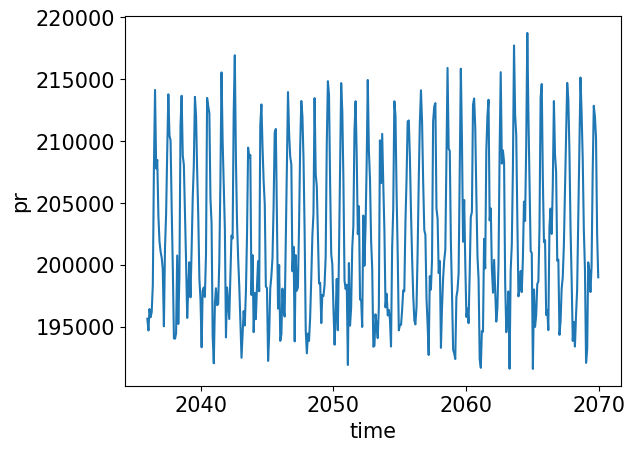

In [6]:
(HiLLA_data['E3SM']['15km'] - ds_ssp245_pr_E3).sum(['latitude', 'longitude']).pr.plot()

In [63]:
SSP245_data['UKESM'].mean('Ensemble_member')['pr'].mean().values

array(2.6669881)

In [8]:
SSP245_data['E3SM'].mean('Ensemble_member')['pr'].mean().values

array(3.20076225)

In [9]:
SSP245_data['CESM'].mean('Ensemble_member')['pr'].mean().values

array(2.48222353)

In [10]:
HiLLA_data['UKESM']['15km']['pr'].mean()

<xarray.DataArray 'pr' ()> Size: 8B
array(2.59017003)

In [11]:
HiLLA_data['E3SM']['15km']['pr'].mean()

<xarray.DataArray 'pr' ()> Size: 8B
array(3.12267827)

In [12]:
HiLLA_data['CESM']['15km']['pr'].mean()

<xarray.DataArray 'pr' ()> Size: 8B
array(3.03654612)

In [13]:
out_dicts = []
for model in models:
    alt_deltas = []
    for alt in HiLLA_altitudes:
        print(model, alt)
        HiLLA_pr = HiLLA_data[model][alt]['pr']
        ssp245_pr = SSP245_data[model].mean('Ensemble_member')['pr']
        annual_delta = get_time_slice_mean(HiLLA_pr) - get_time_slice_mean(ssp245_pr)
        JJA_delta = get_time_slice_mean(HiLLA_pr.where(HiLLA_pr.time.dt.month.isin([6, 7, 8]), drop=True)) - get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([6, 7, 8]), drop=True))
        DJF_delta = get_time_slice_mean(HiLLA_pr.where(HiLLA_pr.time.dt.month.isin([12, 1, 2]), drop=True)) - get_time_slice_mean(ssp245_pr.where(ssp245_pr.time.dt.month.isin([12, 1, 2]), drop=True))
        alt_deltas.append({'Annual':annual_delta, 'JJA':JJA_delta, 'DJF':DJF_delta})
    out_dict = dict(zip(HiLLA_altitudes, alt_deltas))
    out_dicts.append(out_dict)
HiLLA_pr_deltas = dict(zip(models, out_dicts))

UKESM 13km
UKESM 15km
CESM 13km
CESM 15km
E3SM 13km
E3SM 15km


In [15]:
import xarray as xr
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

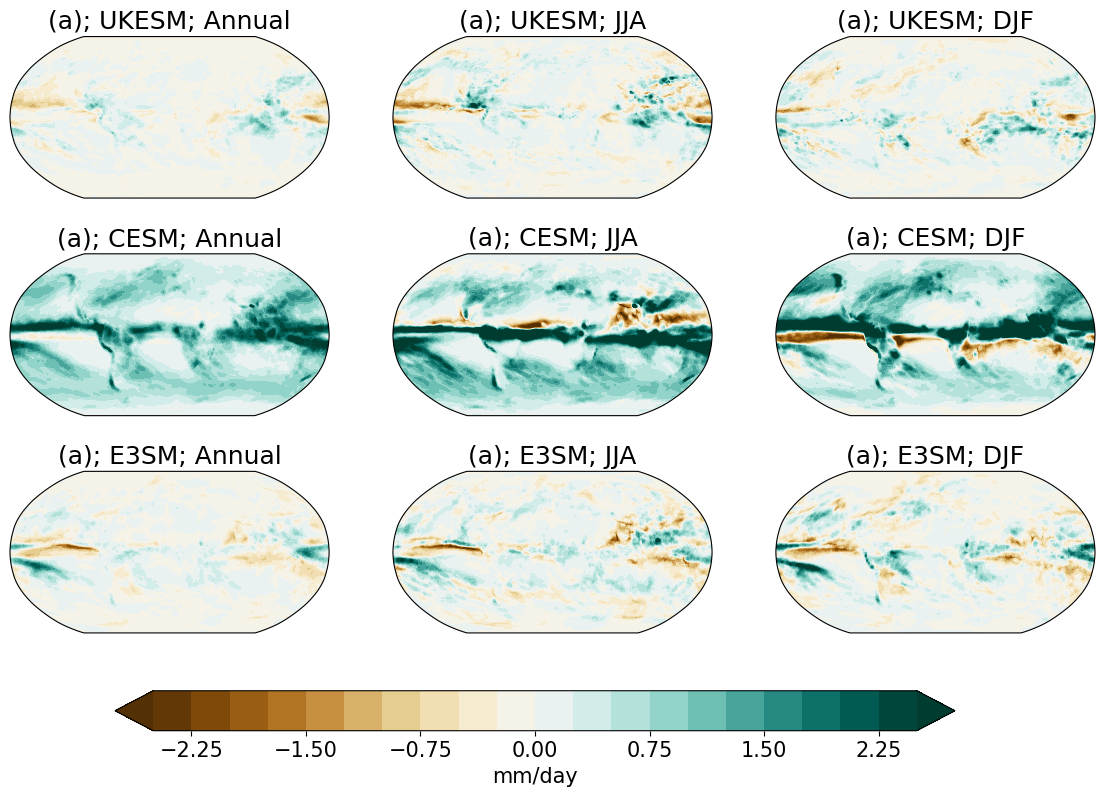

In [29]:
cols = 'BrBG'

fig, axs = plt.subplots(nrows=3,ncols=3,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(14,8))

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '13km'

i=0
for model in models:
    for season in ['Annual', 'JJA', 'DJF']:
        ax = axs.flatten()[i]
        ds = HiLLA_pr_deltas[model][alt][season]
        data,lons=add_cyclic_point(ds,coord=ds['longitude'])
        cs=ax.contourf(lons,ds['latitude'],data,
                       levels=np.arange(-2.5, 2.6, 0.25),
                       transform = ccrs.PlateCarree(),
                       cmap=cols,
                       extend='both')
        ax.set_title(str(titles[0]+'; '+model+'; '+season))
        i=i+1


# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0, 0.6, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal')
cbar.set_label('mm/day', rotation=0)
cbar.ax.yaxis.label.set_va('center')

plt.savefig('Figures/Precip_maps.jpg', dpi=300)

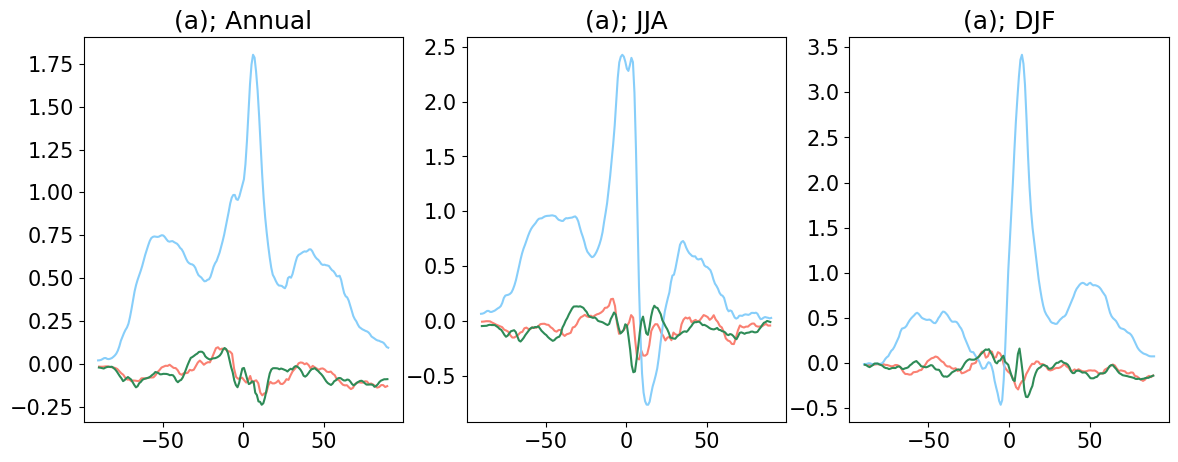

In [30]:
## now plot zonally, for abs difference, and diff vs world at same global temp, and at same trop temp. 


fig, axs = plt.subplots(nrows=1,ncols=3,
                        figsize=(14,5))

titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']

alt = '13km'

i=0
for season in ['Annual', 'JJA', 'DJF']:
    ax = axs[i]
    for model in models:
        ds = HiLLA_pr_deltas[model][alt][season].mean('longitude')
        ax.plot(ds.latitude, ds.values, c=model_colors[model])
    ax.set_title(str(titles[0]+'; '+season))    
    i=i+1


plt.savefig('Figures/Precip_zonal.jpg', dpi=300)

In [ ]:
## final (ambitious) plot : assess the change in amplitude of centroid seasonality..

In [45]:

def get_TPC(da_pr):
    """ returns the latitude defining two regions of equal area-integrated 
    precipitation between two tropical latitude boundaries """
    da_pr = da_pr.sel(latitude=slice(-23, 23))
    weights = np.cos(np.deg2rad(da_pr.latitude))
    da_pr_zonal = da_pr.mean(dim='longitude')
    da_pr_zonal_weighted = da_pr_zonal*weights
    pr_weighted_lats = da_pr.latitude.weighted(da_pr_zonal_weighted)
    centroid = pr_weighted_lats.mean(dim='latitude')
    return centroid
    
def get_annual_amplitude(TPC_ts):
    annual_max = TPC_ts.groupby(TPC_ts.time.dt.year).max()
    annual_min = TPC_ts.groupby(TPC_ts.time.dt.year).min()
    annual_amp = annual_max - annual_min
    return annual_amp

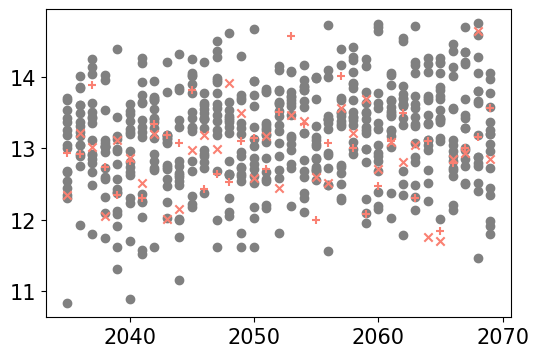

In [65]:
model = 'UKESM'
#alt = '15km'

fig, ax = plt.subplots(nrows=1,ncols=1,
                        figsize=(6,4))

for i in range(len(ens_mems_UK_ssp245_all)):
    amps_ssp245 = get_annual_amplitude(get_TPC(SSP245_data[model].isel(Ensemble_member=i)['pr']))
    ax.scatter(amps_ssp245.year, amps_ssp245, c='gray')

markers = {'13km':'x', '15km':'+'}
for alt in ['13km', '15km']:
    amps_HiLLA = get_annual_amplitude(get_TPC(HiLLA_data[model][alt]['pr']))
    ax.scatter(amps_HiLLA.year, amps_HiLLA, c=model_colors[model], marker=markers[alt])


ValueError: The 'color' keyword argument must have one color per dataset, but 16 datasets and 1 colors were provided

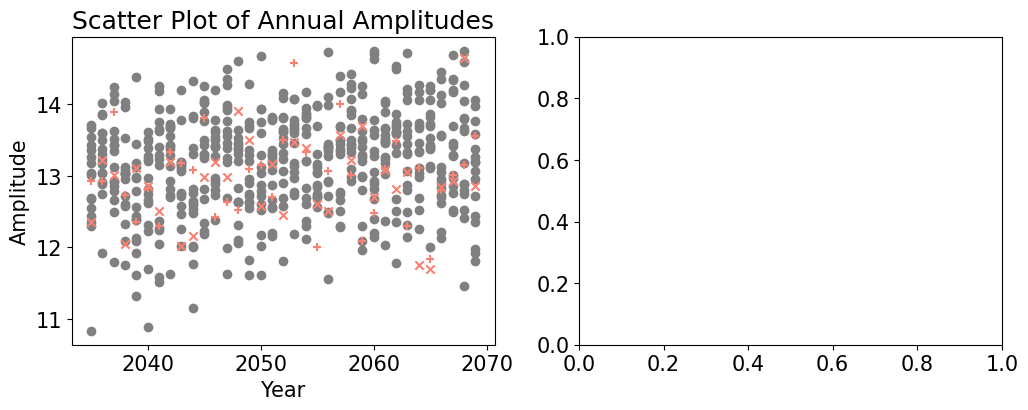

In [68]:

# Create two subplots: one for the scatter plot, and one for the histogram.
# The figsize is increased to accommodate both plots.
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

# ----- First subplot: Scatter plot (original user request) -----

# Loop for SSP245 data and plot on the first axis (ax1)
for i in range(len(ens_mems_UK_ssp245_all)):
    amps_ssp245 = get_annual_amplitude(get_TPC(SSP245_data[model].isel(Ensemble_member=i)['pr']))
    ax1.scatter(amps_ssp245.year, amps_ssp245, c='gray')

# Loop for HiLLA data and plot on the first axis (ax1)
markers = {'13km':'x', '15km':'+'}
for alt in ['13km', '15km']:
    amps_HiLLA = get_annual_amplitude(get_TPC(HiLLA_data[model][alt]['pr']))
    ax1.scatter(amps_HiLLA.year, amps_HiLLA, c=model_colors[model], marker=markers[alt])

ax1.set_xlabel('Year')
ax1.set_ylabel('Amplitude')
ax1.set_title('Scatter Plot of Annual Amplitudes')


# ----- Second subplot: Histograms for the year range 2050-2069 -----

# Initialize lists to store the amplitudes for the histograms
ssp245_amps_hist = []
hilla_amps_hist = []

# Filter SSP245 data for the specified time range and collect amplitudes
for i in range(len(ens_mems_UK_ssp245_all)):
    amps_ssp245_filtered = get_annual_amplitude(get_TPC(SSP245_data[model].isel(Ensemble_member=i)['pr'].sel(time=slice('2050', '2069'))))
    ssp245_amps_hist.append(amps_ssp245_filtered.values)

# Filter HiLLA data for the specified time range and collect amplitudes
for alt in ['13km', '15km']:
    amps_HiLLA_filtered = get_annual_amplitude(get_TPC(HiLLA_data[model][alt]['pr'].sel(time=slice('2050', '2069'))))
    hilla_amps_hist.append(amps_HiLLA_filtered.values)

# Plot the histograms on the second axis (ax2)
ax2.hist(ssp245_amps_hist, bins=20, alpha=0.5, label='SSP245', color='gray')
ax2.hist(hilla_amps_hist, bins=20, alpha=0.5, label='HiLLA', color=model_colors[model])

ax2.set_xlabel('Amplitude')
ax2.set_ylabel('Frequency')
ax2.set_title('Histogram of Amplitudes (2050-2069)')
ax2.legend()

# Adjust layout to prevent labels from overlapping
plt.tight_layout()

# Save the plot
#plt.savefig('scatter_and_histogram_plot.png')

In [69]:
ssp245_amps_hist

[array([12.52164043, 13.79825041, 13.80494311, 13.17672082, 12.11558315,
        12.85147898, 14.73147226, 13.37872637, 13.39439921, 12.99054459,
        13.05462364, 13.25868018, 13.62004969, 13.62448881, 12.69762089,
        13.39335131, 12.96234399, 12.97758142, 14.58710475, 13.20013016]),
 array([13.29869002, 13.18786638, 13.65393227, 14.0757349 , 13.95338921,
        12.69003759, 13.39401624, 13.34381017, 12.98960936, 13.25953584,
        12.93568101, 13.49075376, 12.68427787, 13.31232336, 13.11247125,
        13.69280996, 13.56648039, 12.76060124, 12.52051205, 12.72426839]),
 array([12.71456262, 12.87229826, 14.09548207, 12.78126866, 12.60583884,
        13.98512398, 13.99507852, 12.50409867, 13.43881236, 12.994038  ,
        13.78247659, 14.02615857, 13.62158235, 13.33765361, 12.25861768,
        13.10773924, 12.21441265, 13.28969594, 11.46450097, 11.91588517]),
 array([12.86906797, 13.82646267, 13.32789022, 13.64344109, 12.30255869,
        13.16775493, 13.40853854, 12.28135229